# SMART PROPERTY VALUER  
## Latihan Model Ramalan Harga Hartanah Menggunakan Random Forest dan XGBoost

Notebook ini digunakan untuk melatih model pembelajaran mesin bagi meramalkan harga hartanah berdasarkan faktor:
`Built_Up_SF`, `Bathroom`, `Furnishing`, `Bedroom`, `Tenure`, `Car_Park`, `Property_Type`, `Land_Size`, `Unit_Type`, dan `negeri`.

Nota: Atribut `Price_PSFLand` tidak digunakan kerana ia bergantung kepada harga hartanah dan boleh menyebabkan data leakage.

## 1. Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

## 2. Load Dataset

In [34]:
# Untuk Google Colab, pastikan fail dataset sudah di-upload ke /content/
# Jika nama fail berbeza, tukar path di bawah.

df = pd.read_csv('/content/dataset_with_negeri_filled.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5981, 22)


,Property_ID,Price,Built_Up_SF,Bathroom,Furnishing,Bedroom,Tenure,Car_Park,Agent_Name,Desc,...,Property_Type,Property_Address,Occupancy,Unit_Type,Land_Size,Price_PSFLand,full_address,Latitude,Longitude,negeri
0,P01,600000,1400.0,4.0,1,5.0,1,2.0,Shahrizal Shahrir,Tell shahrizal shahrir you saw this ad from Du...,...,1.0,"Taman Sri Kenari, Kajang - Terrace House For Sale",0.0,0,1400.0,428.571429,"Taman Sri Kenari, Kajang , Malaysia",2.991804,101.769137,Selangor
1,P02,420000,1365.0,3.0,1,4.0,2,2.0,Md Razif Bin Mohd Salim,Tell MD RAZIF BIN MOHD SALIM you saw this ad f...,...,1.0,"Taman Sentosa, Klang - Terrace House For Sale",NaN,1,1170.0,358.974359,"Taman Sentosa, Klang , Malaysia",3.009219,101.467582,Selangor
2,P03,620000,1800.0,3.0,1,4.0,1,2.0,Rafedah Abdul Aziz,Tell RAFEDAH ABDUL AZIZ you saw this ad from D...,...,1.0,"Bandar Pinggiran Subang, Shah Alam - Terrace H...",0.0,0,1400.0,442.857143,"Bandar Pinggiran Subang, Shah Alam , Malaysia",3.159791,101.549091,Selangor
3,P04,470000,1694.0,2.0,3,2.0,1,0.0,Junaidi Bin Mat Alham,Tell Junaidi Bin Mat Alham you saw this ad fro...,...,11.0,"Dataran Otomobil, Shah Alam - Office For Sale",2.0,3,1694.0,277.449823,"Dataran Otomobil, Shah Alam , Malaysia",3.064166,101.532735,Selangor
4,P05,195000,650.0,2.0,2,3.0,1,1.0,Halisa Bashri,Tell HALISA BASHRI you saw this ad from Durian...,...,3.0,"Desa Mentari, Petaling Jaya - Apartment For Sale",0.0,0,650.0,300.000000,"Desa Mentari, Petaling Jaya , Malaysia",3.079608,101.617548,Selangor


## 3. Semak Struktur Data

In [35]:
print("Senarai kolum:")
print(df.columns.tolist())

print("\nMaklumat dataset:")
df.info()

print("\nMissing values:")
df.isnull().sum()

Senarai kolum:
['Property_ID', 'Price', 'Built_Up_SF', 'Bathroom', 'Furnishing', 'Bedroom', 'Tenure', 'Car_Park', 'Agent_Name', 'Desc', 'Place', 'Area', 'Property_Type', 'Property_Address', 'Occupancy', 'Unit_Type', 'Land_Size', 'Price_PSFLand', 'full_address', 'Latitude', 'Longitude', 'negeri']

Maklumat dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5981 entries, 0 to 5980
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Property_ID       5981 non-null   object 
 1   Price             5981 non-null   int64  
 2   Built_Up_SF       5981 non-null   float64
 3   Bathroom          5981 non-null   float64
 4   Furnishing        5981 non-null   int64  
 5   Bedroom           5981 non-null   float64
 6   Tenure            5981 non-null   int64  
 7   Car_Park          5981 non-null   float64
 8   Agent_Name        5981 non-null   object 
 9   Desc              5981 non-null   object 
 10  Place   

,0
Property_ID,0
Price,0
Built_Up_SF,0
Bathroom,0
Furnishing,0
Bedroom,0
Tenure,0
Car_Park,0
Agent_Name,0
Desc,0


## 4. Rujukan Label Numerikal Berdasarkan Laporan

In [36]:
# Label ini merujuk kepada transformasi atribut nominal kepada numerikal dalam laporan.
# Furnishing:
# 0 = Unknown
# 1 = Partly Furnished
# 2 = Unfurnished
# 3 = Fully Furnished

# Tenure:
# 0 = Unknown
# 1 = Leasehold
# 2 = Freehold

# Property_Type:
# 0 = Unknown
# 1 = Terrace House
# 2 = Link Bungalow / Semi-Detached House
# 3 = Condominium / Apartment / Serviced Residence
# 4 = Flat
# 5 = Bungalow / Detached House / Villa
# 6 = Townhouse
# 7 = Cluster
# 8 = Low-Cost House
# 9 = Superlink
# 10 = Penthouse
# 11 = Commercial / Non-Residential
# 12 = Land

# Unit_Type:
# 0 = Unknown
# 1 = Intermediate Lot
# 2 = Corner Lot
# 3 = End Lot

## 5. Pilih Atribut Input dan Target

In [37]:
# Atribut input yang digunakan untuk meramal harga hartanah
selected_features = [
    'Built_Up_SF',
    'Bathroom',
    'Furnishing',
    'Bedroom',
    'Tenure',
    'Car_Park',
    'Property_Type',
    'Land_Size',
    'Unit_Type',
    'negeri'
]

target = 'Price'

# Semak jika semua kolum wujud
missing_cols = [col for col in selected_features + [target] if col not in df.columns]

if missing_cols:
    raise ValueError(f"Kolum ini tiada dalam dataset: {missing_cols}")

X = df[selected_features]
y = df[target]

print("Input features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

Input features: ['Built_Up_SF', 'Bathroom', 'Furnishing', 'Bedroom', 'Tenure', 'Car_Park', 'Property_Type', 'Land_Size', 'Unit_Type', 'negeri']
X shape: (5981, 10)
y shape: (5981,)


,Built_Up_SF,Bathroom,Furnishing,Bedroom,Tenure,Car_Park,Property_Type,Land_Size,Unit_Type,negeri
0,1400.0,4.0,1,5.0,1,2.0,1.0,1400.0,0,Selangor
1,1365.0,3.0,1,4.0,2,2.0,1.0,1170.0,1,Selangor
2,1800.0,3.0,1,4.0,1,2.0,1.0,1400.0,0,Selangor
3,1694.0,2.0,3,2.0,1,0.0,11.0,1694.0,3,Selangor
4,650.0,2.0,2,3.0,1,1.0,3.0,650.0,0,Selangor


## 6. Semak Missing Value Pada Atribut Terpilih

In [38]:
missing_selected = X.isnull().sum()
missing_selected[missing_selected > 0]

,0
Property_Type,14


## 7. Pra-pemprosesan Data

In [39]:
# Atribut numerikal termasuk atribut yang sudah dilabelkan sebagai kod integer dalam laporan
numeric_features = [
    'Built_Up_SF',
    'Bathroom',
    'Furnishing',
    'Bedroom',
    'Tenure',
    'Car_Park',
    'Property_Type',
    'Land_Size',
    'Unit_Type'
]

# Negeri masih berbentuk kategori teks, jadi perlu OneHotEncoding
categorical_features = ['negeri']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 8. Pembahagian Data 80:10:10

In [40]:
# Split pertama: 80% training, 20% sementara
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Split kedua: 10% validation, 10% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

Training set: (4784, 10)
Validation set: (598, 10)
Testing set: (599, 10)


## 9. Latih Model Random Forest

In [41]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


## 10. Penilaian Random Forest

In [42]:
pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 81140.23420732675
RMSE: 122213.99257269305
R²: 0.7227309184495805


Hyperparameter Tuning Random Forest

In [43]:
# OneHotEncoding untuk negeri
X = pd.get_dummies(X, columns=['negeri'], drop_first=True)

# Pastikan semua column jadi numeric
X = X.astype(float)

# Check tiada object/string
print(X.dtypes)

Built_Up_SF               float64
Bathroom                  float64
Furnishing                float64
Bedroom                   float64
Tenure                    float64
Car_Park                  float64
Property_Type             float64
Land_Size                 float64
Unit_Type                 float64
negeri_Kedah              float64
negeri_Kelantan           float64
negeri_Malacca            float64
negeri_Negeri Sembilan    float64
negeri_Pahang             float64
negeri_Penang             float64
negeri_Perak              float64
negeri_Perlis             float64
negeri_Putrajaya          float64
negeri_Sabah              float64
negeri_Sarawak            float64
negeri_Selangor           float64
negeri_Terengganu         float64
dtype: object


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4784, 22)
Validation: (598, 22)
Test: (599, 22)


In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(grid_rf.best_params_)

Best Random Forest Parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


12. Train Best Random Forest

In [60]:
best_rf = grid_rf.best_estimator_

pred_rf_tuned = best_rf.predict(X_test)

mae_rf_tuned = mean_absolute_error(y_test, pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, pred_rf_tuned)

print("Random Forest After Tuning")
print("MAE:", mae_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R²:", r2_rf_tuned)

Random Forest After Tuning
MAE: 82153.26060519402
RMSE: 121690.13787556715
R²: 0.7251027813213697


## 11. Latih Model XGBoost

In [61]:
# ==========================================
# LATIH MODEL XGBOOST
# ==========================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb = r2_score(y_test, pred_xgb)

print("XGBoost Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²:", r2_xgb)

XGBoost Results
MAE: 85847.515625
RMSE: 124024.1235889212
R²: 0.7144566774368286


In [62]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

## 12. Penilaian XGBoost

In [63]:
pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb = r2_score(y_test, pred_xgb)

print("XGBoost Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²:", r2_xgb)

XGBoost Results
MAE: 85847.515625
RMSE: 124024.1235889212
R²: 0.7144566774368286


Hyperparameter Tuning XGBoost

In [65]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(grid_xgb.best_params_)

Best XGBoost Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.9}


Train Best XGBoost

In [66]:
best_xgb = grid_xgb.best_estimator_

pred_xgb_tuned = best_xgb.predict(X_test)

mae_xgb_tuned = mean_absolute_error(y_test, pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, pred_xgb_tuned)

print("XGBoost After Tuning")
print("MAE:", mae_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("R²:", r2_xgb_tuned)

XGBoost After Tuning
MAE: 82616.1484375
RMSE: 120433.13404541128
R²: 0.7307525873184204


## 13. Perbandingan Prestasi Model

In [67]:
best_rf = grid_rf.best_estimator_

pred_rf_tuned = best_rf.predict(X_test)

mae_rf_tuned = mean_absolute_error(y_test, pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, pred_rf_tuned)

In [68]:
best_xgb = grid_xgb.best_estimator_

pred_xgb_tuned = best_xgb.predict(X_test)

mae_xgb_tuned = mean_absolute_error(y_test, pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, pred_xgb_tuned)

In [69]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest - Before Tuning',
        'Random Forest - After Tuning',
        'XGBoost - Before Tuning',
        'XGBoost - After Tuning'
    ],
    'MAE': [
        mae_rf,
        mae_rf_tuned,
        mae_xgb,
        mae_xgb_tuned
    ],
    'RMSE': [
        rmse_rf,
        rmse_rf_tuned,
        rmse_xgb,
        rmse_xgb_tuned
    ],
    'R²': [
        r2_rf,
        r2_rf_tuned,
        r2_xgb,
        r2_xgb_tuned
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Random Forest - Before Tuning,81140.234207,122213.992573,0.722731
1,Random Forest - After Tuning,82153.260605,121690.137876,0.725103
2,XGBoost - Before Tuning,85847.515625,124024.123589,0.714457
3,XGBoost - After Tuning,82616.148438,120433.134045,0.730753


## 14. Visualisasi Perbandingan Model

## 15. Actual vs Predicted Price

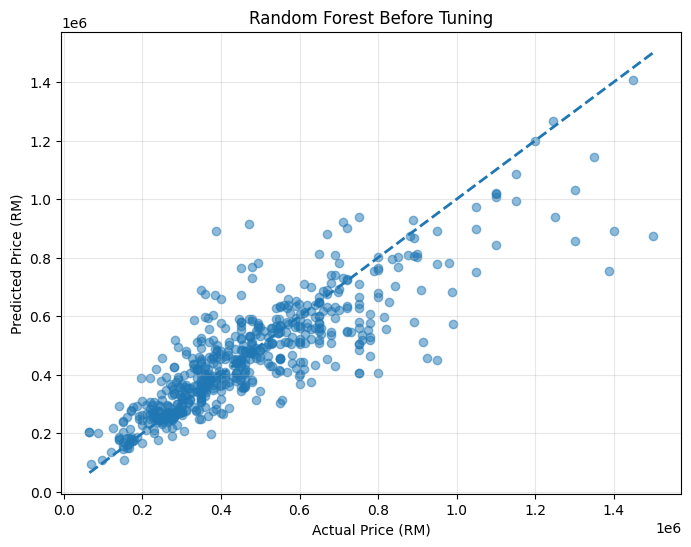

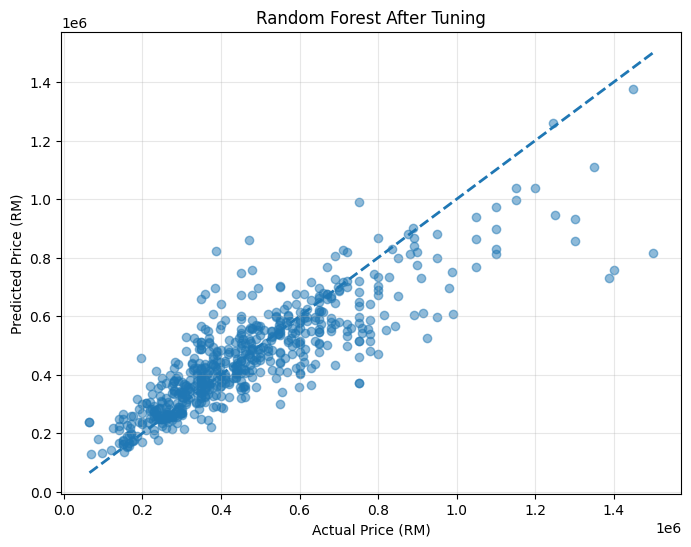

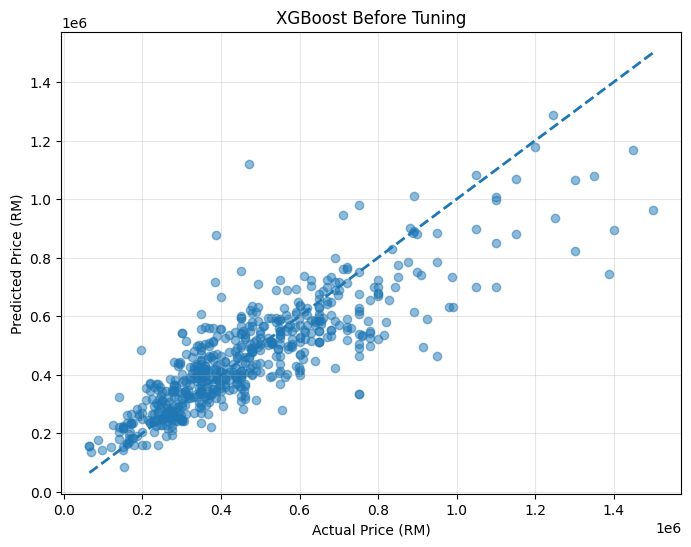

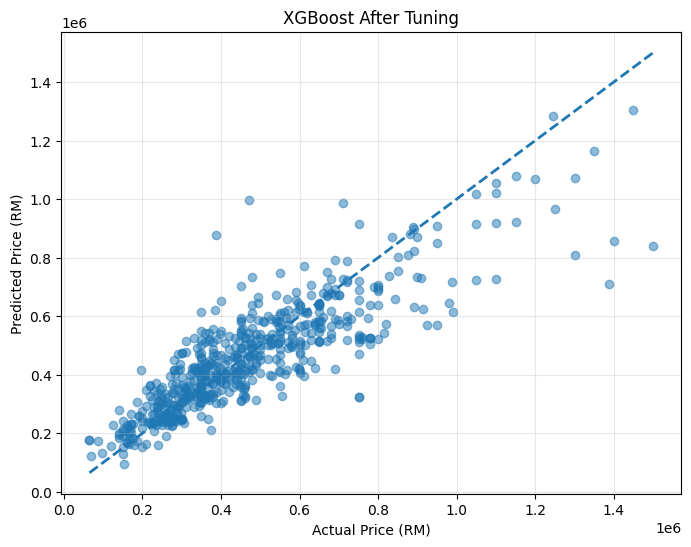

In [74]:
# ==================================================
# RANDOM FOREST - BEFORE TUNING
# ==================================================
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_rf, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    linewidth=2
)

plt.xlabel('Actual Price (RM)')
plt.ylabel('Predicted Price (RM)')
plt.title('Random Forest Before Tuning')
plt.grid(True, alpha=0.3)

plt.show()


# ==================================================
# RANDOM FOREST - AFTER TUNING
# ==================================================
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_rf_tuned, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    linewidth=2
)

plt.xlabel('Actual Price (RM)')
plt.ylabel('Predicted Price (RM)')
plt.title('Random Forest After Tuning')
plt.grid(True, alpha=0.3)

plt.show()


# ==================================================
# XGBOOST - BEFORE TUNING
# ==================================================
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_xgb, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    linewidth=2
)

plt.xlabel('Actual Price (RM)')
plt.ylabel('Predicted Price (RM)')
plt.title('XGBoost Before Tuning')
plt.grid(True, alpha=0.3)

plt.show()


# ==================================================
# XGBOOST - AFTER TUNING
# ==================================================
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_xgb_tuned, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    linewidth=2
)

plt.xlabel('Actual Price (RM)')
plt.ylabel('Predicted Price (RM)')
plt.title('XGBoost After Tuning')
plt.grid(True, alpha=0.3)

plt.show()

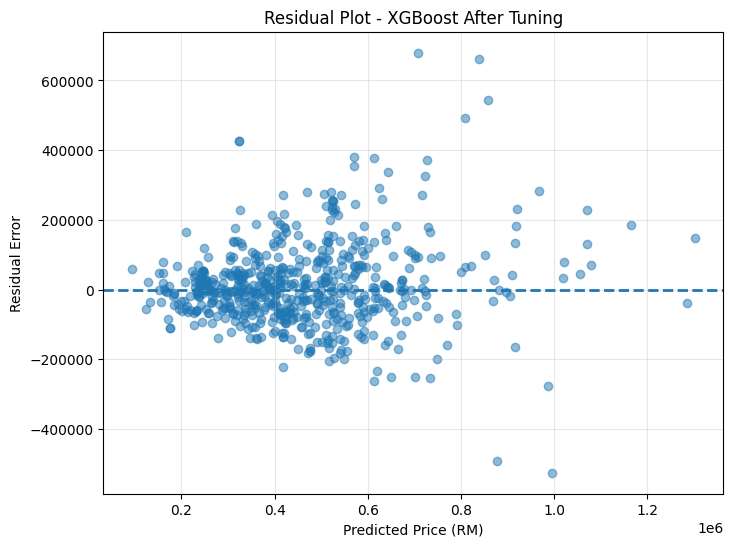

In [89]:
residuals = y_test - pred_xgb_tuned

plt.figure(figsize=(8,6))

plt.scatter(pred_xgb_tuned, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--', linewidth=2)

plt.xlabel('Predicted Price (RM)')
plt.ylabel('Residual Error')
plt.title('Residual Plot - XGBoost After Tuning')

plt.grid(True, alpha=0.3)

plt.show()

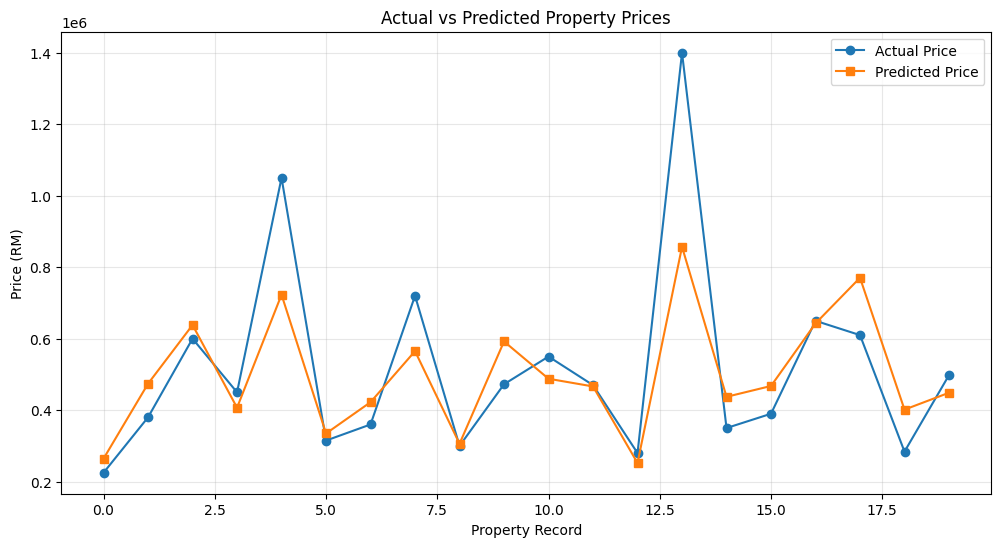

In [90]:
comparison_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': pred_xgb_tuned
})

comparison_df = comparison_df.head(20)

plt.figure(figsize=(12,6))

plt.plot(
    comparison_df.index,
    comparison_df['Actual Price'],
    marker='o',
    label='Actual Price'
)

plt.plot(
    comparison_df.index,
    comparison_df['Predicted Price'],
    marker='s',
    label='Predicted Price'
)

plt.title('Actual vs Predicted Property Prices')
plt.xlabel('Property Record')
plt.ylabel('Price (RM)')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

yang mana influence

In [85]:
importance_df['Category'] = importance_df['Feature'].apply(
    lambda x: 'Negeri' if x.startswith('negeri_') else x
)

grouped_importance = importance_df.groupby('Category')[
    'Importance'
].sum().reset_index()

grouped_importance = grouped_importance.sort_values(
    by='Importance',
    ascending=False
)

grouped_importance

,Category,Importance
6,Negeri,0.548854
0,Bathroom,0.115919
2,Built_Up_SF,0.082592
5,Land_Size,0.070936
7,Property_Type,0.061244
1,Bedroom,0.031625
4,Furnishing,0.026154
8,Tenure,0.024768
3,Car_Park,0.021190
9,Unit_Type,0.016720


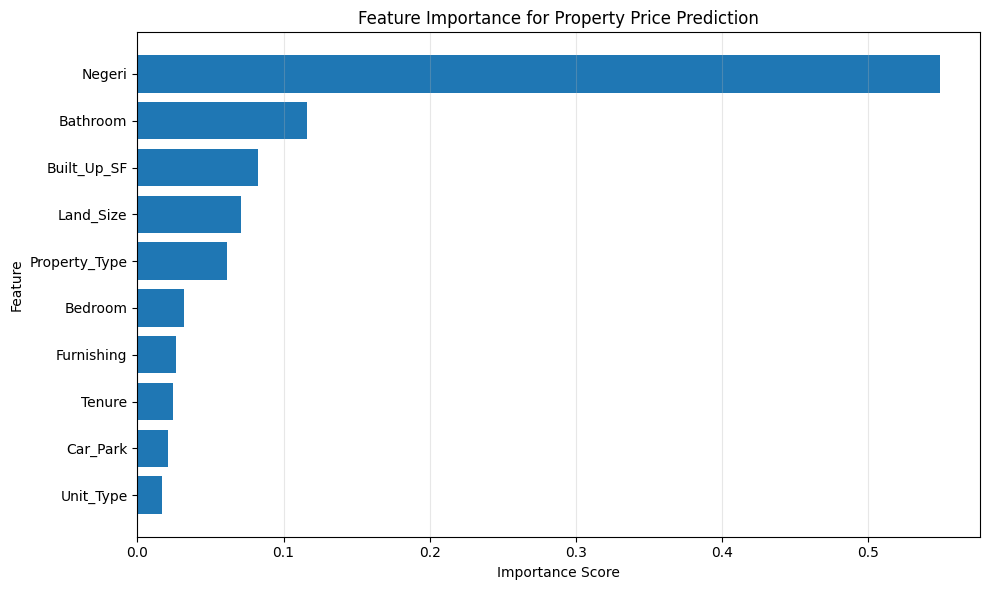

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    grouped_importance['Category'],
    grouped_importance['Importance']
)

plt.title('Feature Importance for Property Price Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

based on negeri before price prediciton

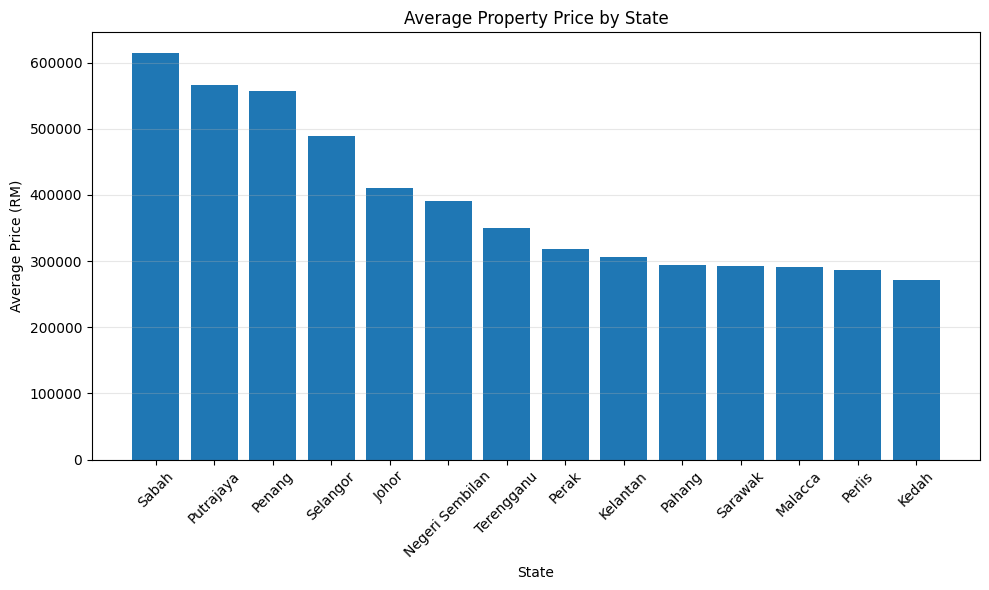

In [78]:
import matplotlib.pyplot as plt

state_price = df.groupby('negeri')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

plt.bar(
    state_price.index,
    state_price.values
)

plt.title('Average Property Price by State')
plt.xlabel('State')
plt.ylabel('Average Price (RM)')

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

berdasarkan price predicted

In [79]:
test_results = X_test.copy()

test_results['Actual_Price'] = y_test.values
test_results['Predicted_Price'] = pred_xgb_tuned

In [80]:
results_df = X_test.copy()

results_df['negeri'] = df.loc[X_test.index, 'negeri']
results_df['Predicted_Price'] = pred_xgb_tuned

In [81]:
state_predicted = results_df.groupby('negeri')['Predicted_Price'].mean()

state_predicted = state_predicted.sort_values(
    ascending=False
)

print(state_predicted)

negeri
Putrajaya          683130.750000
Penang             514484.687500
Sabah              482480.062500
Selangor           476097.093750
Sarawak            410610.468750
Johor              397425.343750
Negeri Sembilan    397023.125000
Perak              387000.187500
Malacca            275047.062500
Kedah              259857.640625
Pahang             250754.953125
Kelantan           240802.062500
Name: Predicted_Price, dtype: float32


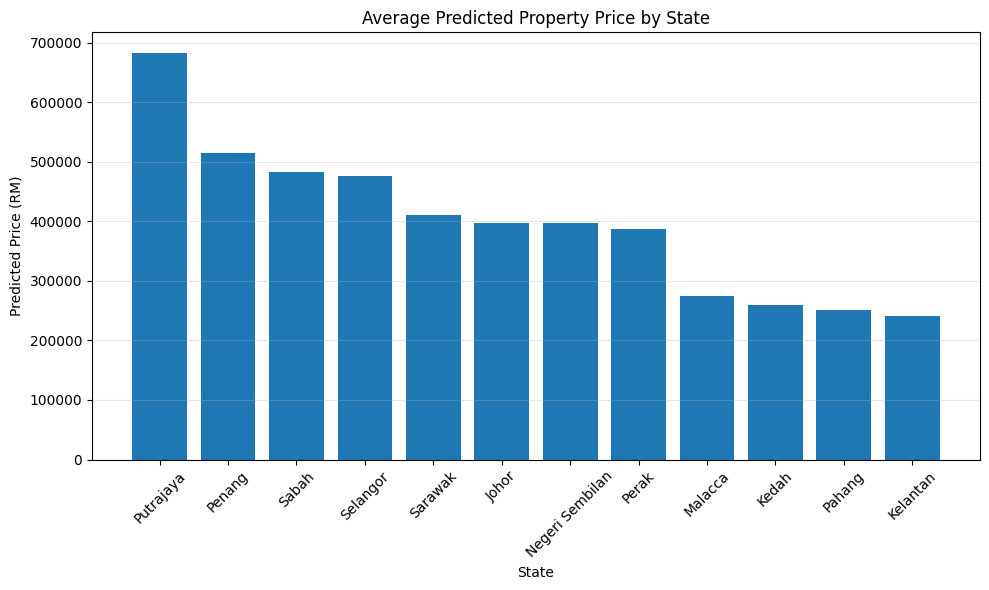

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    state_predicted.index,
    state_predicted.values
)

plt.title('Average Predicted Property Price by State')
plt.xlabel('State')
plt.ylabel('Predicted Price (RM)')

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()